<a href="https://www.kaggle.com/code/adamdandi/a-b-test-leaderboard-automated-conversion-rate?scriptVersionId=328874145" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# A/B Test Leaderboard: Automated Conversion Rate Uplift Ranking

## Overview

This project focuses on the automated extraction and ranking of A/B test results from test report images.

It fits into the context of marketing and product experimentation. Teams run multiple A/B tests and need a fast and repeatable way to compare results.

The script conducts this analysis to help teams decide which product changes to prioritize. It ranks every A/B test by its conversion rate uplift from best to worst.

## Objectives

### Primary Goal

Extract A/B test data from 50 images and rank every test by the relative conversion rate uplift of its variant over its control.

### Specific Goals

- Extract the test name, traffic values, and conversion values from each image using OCR.
- Compute the control conversion rate, the variant conversion rate, and the relative uplift.
- Rank all 50 tests and export the results as a CSV file, a JSON file, and an HTML leaderboard.

**Data Source:** 50 image files. Each image shows one A/B test with a control group and a variant group.

**Success Criteria:** A ranked HTML leaderboard listing all 50 tests with their conversion rates and uplift values, along with structured data exports.

## Solution Approach

### Methodology

The script uses Optical Character Recognition (OCR) through EasyOCR to read text from each image. It then uses regular expressions to identify the required numbers. Finally, it uses pandas to calculate conversion metrics and generate the rankings.

### Key Steps

1. Locate all images in the input directory.
2. Run EasyOCR on each image to extract raw text.
3. Extract the test name and identify the traffic and conversion values.
4. Calculate the control conversion rate, variant conversion rate, and relative uplift.
5. Sort the tests by uplift score and save the output files.

### Tools Used

- Python
- EasyOCR
- pandas
- Regular expressions

### Rationale

EasyOCR performs well on clean digital images and does not require additional system-level installations, making the solution simple to deploy and easy to maintain.

## Expected Outcomes

- A single HTML leaderboard ranking all A/B tests by conversion rate uplift.
- Structured data exports in CSV and JSON formats.
- A repeatable and scalable code structure that can process future batches of similar A/B test images.

In [1]:
# The script installs EasyOCR for reading text from images.
# EasyOCR uses deep learning and runs entirely within Python.
!pip install easyocr --quiet

In [2]:
# The script imports necessary tools for the project.
import os
import re
import glob
import pandas as pd
import easyocr

In [3]:
# The script defines the folder containing the dataset images.
image_dir = "/kaggle/input/datasets/adamdandi/ab-images"

# The script collects all image paths and sorts them to ensure a consistent order.
image_paths = sorted(
    glob.glob(os.path.join(image_dir, "*.png")) +
    glob.glob(os.path.join(image_dir, "*.jpg")) +
    glob.glob(os.path.join(image_dir, "*.jpeg"))
)

# The script prints the total count to verify it found all images.
print(f"Found {len(image_paths)} images")
print("First 3:", image_paths[:3])

Found 50 images
First 3: ['/kaggle/input/datasets/adamdandi/ab-images/AB_Test_01.png', '/kaggle/input/datasets/adamdandi/ab-images/AB_Test_02.png', '/kaggle/input/datasets/adamdandi/ab-images/AB_Test_03.png']


In [4]:
# The script creates the OCR reader tool for English text.
# It sets gpu to False because standard CPU processing is fast enough for this batch.
reader = easyocr.Reader(['en'], gpu=False)
print("EasyOCR reader ready.")

Using CPU. Note: This module is much faster with a GPU.


EasyOCR reader ready.


In [5]:
def extract_test_name(texts):
    """
    The function scans the list of text read by the OCR tool.
    It returns the first line of text that is not empty.
    This first line is typically the title of the test.
    """
    for t in texts:
        if t.strip():
            return t.strip()
    return "Unknown"

In [6]:
# The script prepares a pattern to find numbers, including those with commas.
number_pattern = re.compile(r"\d[\d,]*")

def extract_row_numbers(texts, row_label):
    """
    The function finds the text line containing the row label (Traffic or Conversions).
    It then reads the next two numbers it finds in that section.
    Because OCR reads left to right, the first number belongs to the Control column.
    The second number belongs to the Variant column.
    """
    for i, t in enumerate(texts):
        if row_label.lower() in t.lower():
            # The script groups the current line and the next few lines together.
            segment = " ".join(texts[i : i + 10])
            nums = number_pattern.findall(segment)
            
            if len(nums) >= 2:
                # The script removes commas and converts the text into numbers.
                val_control = int(nums[0].replace(",", ""))
                val_variant = int(nums[1].replace(",", ""))
                return val_control, val_variant
                
    return None, None

In [7]:
def process_image(path, reader):
    """
    The function runs the complete extraction process for a single image.
    It uses the OCR tool to get the text, then pulls the specific data points needed.
    """
    # The script extracts plain text strings from the image.
    texts = reader.readtext(path, detail=0)
    
    test_name = extract_test_name(texts)
    
    # The script looks for the Traffic row to get both traffic numbers.
    c_traffic, v_traffic = extract_row_numbers(texts, "Traffic")
    
    # The script looks for the Conversions row to get both conversion numbers.
    c_conv, v_conv = extract_row_numbers(texts, "Conversions")
    
    return {
        "test_name": test_name,
        "control_traffic": c_traffic,
        "control_conversions": c_conv,
        "variant_traffic": v_traffic,
        "variant_conversions": v_conv,
        "image_file": os.path.basename(path)
    }

In [8]:
# The script loops through every image and processes them one by one.
rows = []
for idx, path in enumerate(image_paths, start=1):
    row = process_image(path, reader)
    rows.append(row)
    
    # The script prints a progress update every 10 images.
    if idx % 10 == 0 or idx == len(image_paths):
        print(f"  [{idx}/{len(image_paths)}] {row['test_name']}")

# The script turns the collected data into a structured pandas table.
df = pd.DataFrame(rows)
print(f"\nDone. DataFrame shape: {df.shape}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

  [10/50] A/B test #10


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

  [20/50] A/B test #20


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

  [30/50] A/B test #30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

  [40/50] A/B test #40


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

  [50/50] A/B test #50

Done. DataFrame shape: (50, 6)


In [9]:
# The script ensures all data columns are treated as numbers.
columns_to_convert = ["control_traffic", "control_conversions", "variant_traffic", "variant_conversions"]
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# The script calculates the conversion rate for both groups.
df["control_cr"] = df["control_conversions"] / df["control_traffic"]
df["variant_cr"] = df["variant_conversions"] / df["variant_traffic"]

# The script calculates how much the variant improved compared to the control.
df["uplift"] = (df["variant_cr"] - df["control_cr"]) / df["control_cr"]

# The script replaces any missing calculation results with a zero.
df[["control_cr", "variant_cr", "uplift"]] = df[["control_cr", "variant_cr", "uplift"]].fillna(0)

# The script sorts the table so the highest uplift is at the top.
df_sorted = df.sort_values("uplift", ascending=False).reset_index(drop=True)
df_sorted["rank"] = df_sorted.index + 1

In [10]:
# The script saves the structured data to files for easy sharing and review.
df_sorted.to_csv("/kaggle/working/ab_tests.csv", index=False)
df_sorted.to_json("/kaggle/working/ab_tests.json", orient="records", indent=2)

print("ab_tests.csv saved")
print("ab_tests.json saved")

ab_tests.csv saved
ab_tests.json saved


In [11]:
def fmt_pct(x):
    """
    The function formats decimal numbers into percentages for easier reading.
    """
    return f"{x * 100:.2f}%" if pd.notna(x) else "N/A"

def uplift_color(x):
    """
    The function chooses a text color based on the performance result.
    Green indicates a positive change, red indicates a negative change, and grey indicates no change.
    """
    if pd.isna(x) or x == 0: 
        return "#888888"
    return "#2e7d32" if x > 0 else "#c62828"

# The script generates an HTML row for every test in the sorted data.
rows_html = []
for _, r in df_sorted.iterrows():
    color = uplift_color(r["uplift"])
    rows_html.append(f"""
        <tr>
            <td>{int(r['rank'])}</td>
            <td style="text-align:left">{r['test_name']}</td>
            <td>{int(r['control_traffic']) if pd.notna(r['control_traffic']) else 'N/A'}</td>
            <td>{int(r['control_conversions']) if pd.notna(r['control_conversions']) else 'N/A'}</td>
            <td>{fmt_pct(r['control_cr'])}</td>
            <td>{int(r['variant_traffic']) if pd.notna(r['variant_traffic']) else 'N/A'}</td>
            <td>{int(r['variant_conversions']) if pd.notna(r['variant_conversions']) else 'N/A'}</td>
            <td>{fmt_pct(r['variant_cr'])}</td>
            <td style="color:{color}; font-weight:bold">{fmt_pct(r['uplift'])}</td>
        </tr>
    """)

# The script combines the rows with the main structure of the web page.
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>A/B Test Leaderboard</title>
    <style>
        body  {{ font-family: Arial, sans-serif; padding: 30px; background: #f5f5f5; }}
        h1    {{ text-align: center; color: #333; }}
        p.sub {{ text-align: center; color: #666; margin-top: -10px; }}
        table {{ border-collapse: collapse; width: 100%; background: white; 
                 box-shadow: 0 2px 4px rgba(0,0,0,.1); border-radius: 8px; overflow: hidden; }}
        th    {{ background: #1565c0; color: white; padding: 12px 10px; text-align: center; }}
        td    {{ border: 1px solid #e0e0e0; padding: 9px 10px; text-align: right; font-size: 13px; }}
        tr:nth-child(even) {{ background: #f9f9f9; }}
        tr:hover           {{ background: #e3f2fd; }}
    </style>
</head>
<body>
    <h1>A/B Test Leaderboard</h1>
    <p class="sub">Ranked by Conversion Rate Uplift (Best to Worst) | Total Tests: {len(df_sorted)}</p>
    <table>
        <thead>
            <tr>
                <th>Rank</th><th>Test Name</th>
                <th>Control Traffic</th><th>Control Conv.</th><th>Control CR</th>
                <th>Variant Traffic</th><th>Variant Conv.</th><th>Variant CR</th>
                <th>Uplift</th>
            </tr>
        </thead>
        <tbody>
            {"".join(rows_html)}
        </tbody>
    </table>
</body>
</html>
"""

# The script writes the final web page string into a file.
with open("/kaggle/working/leaderboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("leaderboard.html saved")

leaderboard.html saved


In [12]:
from IPython.display import HTML, display

# Open and read the HTML file you just saved
with open("/kaggle/working/leaderboard.html", "r", encoding="utf-8") as file:
    leaderboard_html = file.read()

# Show the HTML right here in the notebook cell output
display(HTML(leaderboard_html))

Rank,Test Name,Control Traffic,Control Conv.,Control CR,Variant Traffic,Variant Conv.,Variant CR,Uplift
1,A/B test #17,17600,528,3.00%,17680,651,3.68%,22.74%
2,A/B test #43,11040,397,3.60%,11120,489,4.40%,22.29%
3,A/B test #24,8980,359,4.00%,9020,433,4.80%,20.08%
4,A/B test #23,13350,467,3.50%,13420,552,4.11%,17.58%
5,A/B test #05,13350,467,3.50%,13420,552,4.11%,17.58%
6,A/B test #12,6640,219,3.30%,6690,258,3.86%,16.93%
7,A/B test #50,7020,246,3.50%,7080,289,4.08%,16.48%
8,A/B test #28,18450,553,3.00%,18510,642,3.47%,15.72%
9,A/B test #42,15540,482,3.10%,15590,559,3.59%,15.60%
10,A/B test #41,15010,450,3.00%,15080,521,3.45%,15.24%


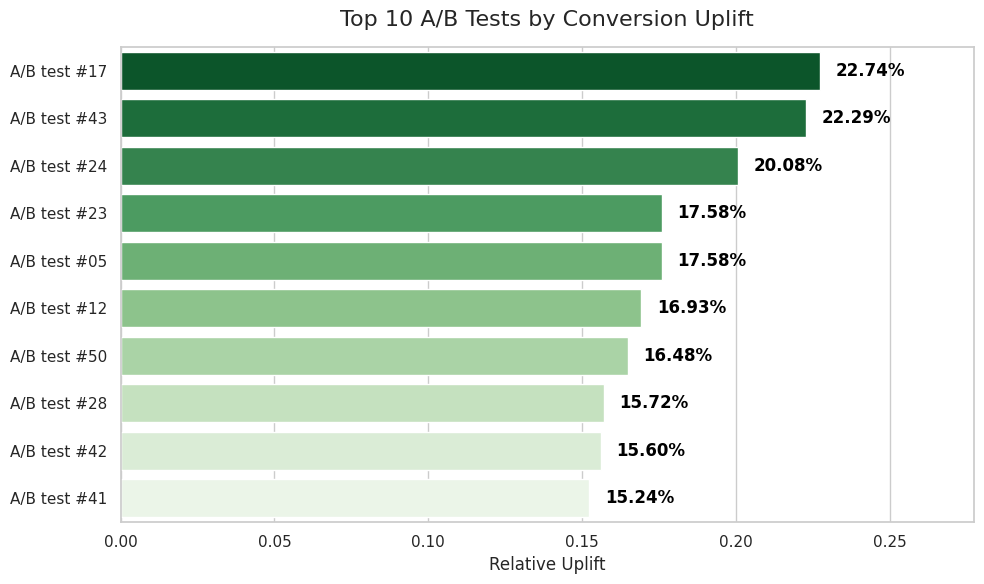

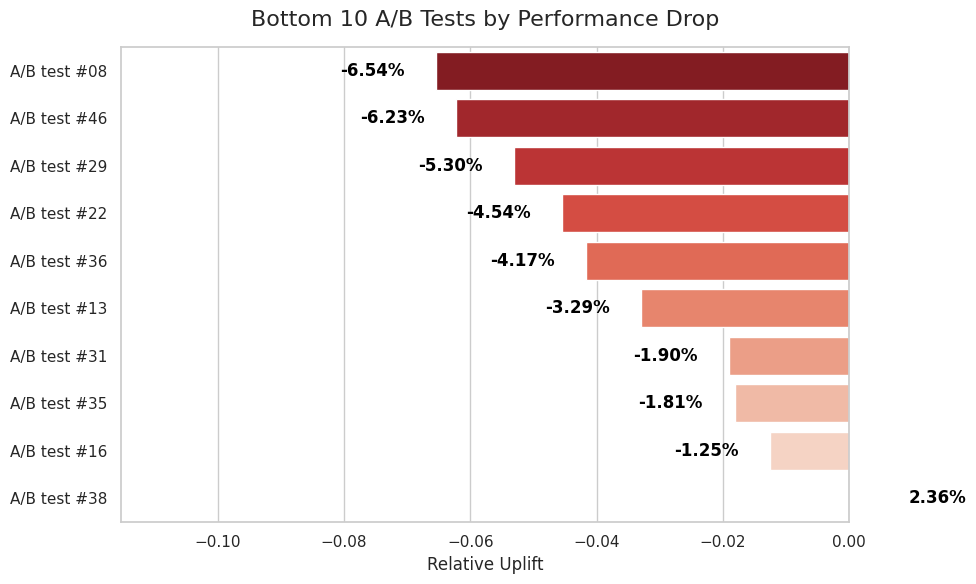

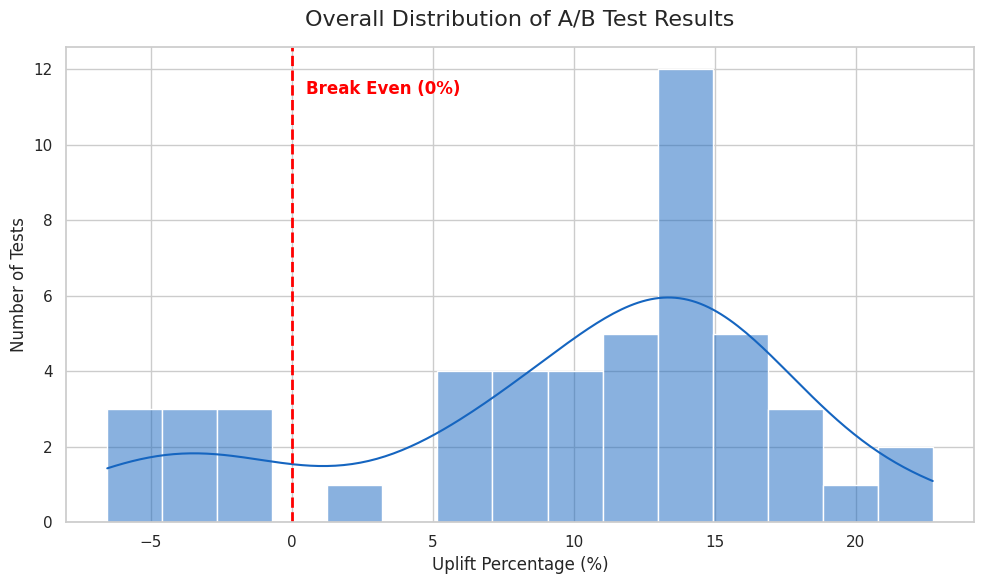

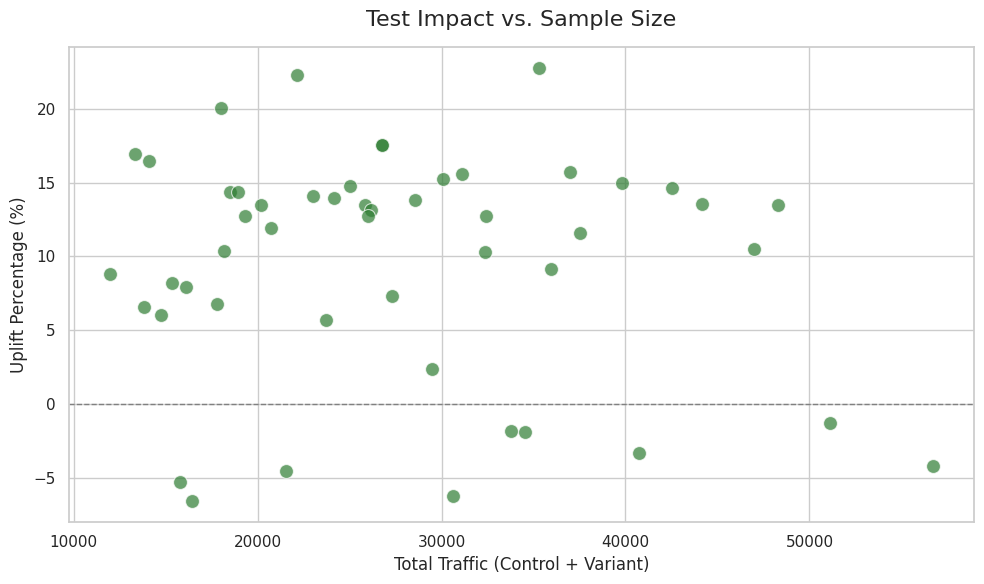

All charts have been generated and saved to the working directory.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a clean visual style for the charts
sns.set_theme(style="whitegrid")

# Create the top 10 and bottom 10 subsets
top_10 = df_sorted.head(10)
# Sort bottom 10 ascending so the worst performer is at the top of the chart
bottom_10 = df_sorted.tail(10).sort_values("uplift", ascending=True)

# ---------------------------------------------------------
# Chart 1: Top 10 Winners
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Assigning y to hue and setting legend=False fixes the Seaborn warning
ax1 = sns.barplot(data=top_10, x="uplift", y="test_name", hue="test_name", palette="Greens_r", legend=False)

# Add percentage labels to the end of each bar
for index, row in enumerate(top_10.itertuples()):
    # offset slightly to the right of the bar
    ax1.text(row.uplift + 0.005, index, f"{row.uplift*100:.2f}%", color='black', va="center", fontweight='bold')

plt.title("Top 10 A/B Tests by Conversion Uplift", fontsize=16, pad=15)
plt.xlabel("Relative Uplift", fontsize=12)
plt.ylabel("")
# Extend x-axis slightly so labels don't get cut off
plt.xlim(0, top_10['uplift'].max() + 0.05) 

plt.tight_layout()
plt.savefig("/kaggle/working/chart_top10_winners.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Chart 2: Bottom 10 Losers
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(data=bottom_10, x="uplift", y="test_name", hue="test_name", palette="Reds_r", legend=False)

# Add percentage labels to the end of each bar
for index, row in enumerate(bottom_10.itertuples()):
    # offset slightly to the left of the bar since values are negative
    ax2.text(row.uplift - 0.005, index, f"{row.uplift*100:.2f}%", color='black', ha='right', va="center", fontweight='bold')

plt.title("Bottom 10 A/B Tests by Performance Drop", fontsize=16, pad=15)
plt.xlabel("Relative Uplift", fontsize=12)
plt.ylabel("")
plt.xlim(bottom_10['uplift'].min() - 0.05, 0)

plt.tight_layout()
plt.savefig("/kaggle/working/chart_bottom10_losers.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Chart 3: Distribution of All 50 Tests
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Multiply by 100 to show whole percentages on the x-axis
ax3 = sns.histplot(df_sorted['uplift'] * 100, bins=15, kde=True, color="#1565c0")

# Draw a vertical line at 0% to clearly separate winners from losers
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.text(0.5, ax3.get_ylim()[1]*0.9, 'Break Even (0%)', color='red', weight='bold')

plt.title("Overall Distribution of A/B Test Results", fontsize=16, pad=15)
plt.xlabel("Uplift Percentage (%)", fontsize=12)
plt.ylabel("Number of Tests", fontsize=12)

plt.tight_layout()
plt.savefig("/kaggle/working/chart_distribution.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Chart 4: Test Size (Traffic) vs. Uplift
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Use total traffic (control + variant) for the x-axis
total_traffic = df_sorted['control_traffic'] + df_sorted['variant_traffic']

ax4 = sns.scatterplot(x=total_traffic, y=df_sorted['uplift'] * 100, alpha=0.7, color="#2e7d32", s=100)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.title("Test Impact vs. Sample Size", fontsize=16, pad=15)
plt.xlabel("Total Traffic (Control + Variant)", fontsize=12)
plt.ylabel("Uplift Percentage (%)", fontsize=12)

plt.tight_layout()
plt.savefig("/kaggle/working/chart_traffic_vs_uplift.png", dpi=300)
plt.show()

print("All charts have been generated and saved to the working directory.")

## What the Data Shows

- Most tests are successful. The distribution visual shows a strong concentration of results on the positive side of the 0% mark. The largest cluster of tests improved performance by 10% to 15%.

- Wins are significantly larger than losses. The top winners visual highlights maximum gains reaching 22.74%. The worst performing test only caused a 6.54% drop. The potential rewards far outweigh the negative risks.

- High visitor pages show flat results. The scatter plot compares the number of visitors to the test impact. The tests with the largest audience sizes sit completely flat near the 0% mark. The massive 20% improvements only happen on pages with medium visitor numbers.

## Business Impactd

This testing program is highly effective and directly improves company revenue. Pushing successful tests live increases customer purchases and engagement. The limited size of the negative tests protects the business from costly design errors.

Leadership must pay attention to the flat results on high visitor pages. These pages represent the largest total audience. Failing to improve these specific areas leaves significant money uncollected. Unlocking growth on the highest visitor pages is required to maximize overall business profit.

## Action Plan
- Quick Win: Deploy the top 10 winning features permanently. Pushing changes from tests like A/B test #17 to all users will capture the 22% improvement today and immediately increase daily sales.

- Deep Dive: Investigate the pages with the highest visitor numbers. The team needs to analyze user behavior on these specific pages to understand why new ideas fail to create a positive impact.

- Long Game: Increase the total number of monthly tests. The data proves the downside risk is very low while the upside is high. Testing more radical ideas over the next six months will speed up overall company growth.